In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Making Light Cones and Mock Cubes for TIM

The workbook contains the code necessary to make light cones (catalogs) and mock
data cubes for simulating TIM observations.

For our underlying model of the signal we use halos from the Illustris TNG simulations
with new SFRs and halo masses assigned using the prescription from Behroozi et al. 2013.
We then paint line luminosities using the SFR-luminosity scaling relations from
Spinoglio et al. 2012 (as updated in the 2014 erratum for that paper) for CII, OIII 88um,
and NII 122um, and Zhao et al. 2013 for NII 205um. See the ``tim_modely.ipynb`` workbook
for a general forecast of the signal this model will produce, along with some alternative
modeling options.

## Generating Light Cones from Illustris TNG

The first step is to construct a light cone from the redshift snapshots of the Illustris TNG
simulations. SimIM has features for doing this built in.

In [6]:
# Compute how much simulation volume a given lightcone size needs:
from astropy.cosmology import Planck18 as cosmo
z1 = 0.5
z2 = 1.7
area = 0.1 # square degrees
v1 = 1/3 * cosmo.comoving_distance(z1)**3 * (area*(np.pi/180)**2)
v2 = 1/3 * cosmo.comoving_distance(z2)**3 * (area*(np.pi/180)**2)
v = (v2-v1).value

print("A TIM field of {} square degrees corresponds to a {:.0f} Mpc^3 volume for CII. This is {:.0f}% of the TNG300 volume".format(area,v,v/300**3*100))

A TIM field of 0.1 square degrees corresponds to a 1072443 Mpc^3 volume for CII. This is 4% of the TNG300 volume


In [3]:
# Set the simulation to use and light cone parameters
simname = 'TNG100-3-Dark'
simname = 'TNG100-3-Dark'

mode = 'box'
openangle = np.sqrt(0.2) # A 0.2 square degree field - larger than GOODS-S
aspect = 1
redshift_min = 0
redshift_max = 4.0

if simname == 'TNG100-3-Dark':  # Low resolutions sim for testing and development
    minimum_mass = 1e10
    number_of_lc = 1
else:
    minimum_mass = 1e9
    number_of_lc = 1

In [4]:
# Generate the light cone
import simim.lightcone as lc

rng_seed_lc = 694944739

maker = lc.make.lightcone(simname,'TIM',openangle=openangle,aspect=aspect,redshift_min=redshift_min,redshift_max=redshift_max,minimum_mass=minimum_mass,mode=mode)
maker.build_lightcones(number_of_lc,rng=np.random.default_rng(rng_seed_lc))

ValueError: Simulation TNG100-3-Dark not available. Try installing it or updating the path

The above code will create a catalog of subhalos in the light cone with a minimal 
set of properties - positions, and halo masses. We will want to add a number of
additional properties, such as SFRs, stellar masses, and line luminosities. If 
these properties are already defined in the parent simulation, we can simply copy 
them. Alternatively, we can define new properties and apply them to the light cone.
We'll do the latter in this case.

The properties we'll add are SFR and stellar mass from the Behroozi et al. 2013 
prescription, and CII, OIII, and NII luminosities.

In [5]:
# Load the relevant properties
rng_properties = np.random.default_rng(327903736)
default_scatter = 0.4 # based on DeLooze fit for whole CII sample

# For Behroozi et al. SFRs and stellar masses:
from simim.lineprops.lineprops import prop_behroozi_sfr, prop_behroozi_mass
kws_behroozi = {'rng':rng_properties}

# For spinoglio et al:
from simim.lineprops.lineprops import prop_spinoglio_fir
kws_spinoglio_cii = {'line':'[CII]','sig_scatter':default_scatter,'rng':rng_properties}
kws_spinoglio_nii = {'line':'[NII]','sig_scatter':default_scatter,'rng':rng_properties}
kws_spinoglio_oiii = {'line':'[OIII]88um','sig_scatter':default_scatter,'rng':rng_properties}

# For Zhao et al.
from simim.lineprops.lineprops import prop_zhao_nii
kws_zhao_nii = {'sig_scatter':default_scatter,'rng':rng_properties}

In [6]:
# Apply each property to the light cone
props = [prop_behroozi_sfr,prop_behroozi_mass,prop_spinoglio_fir,prop_spinoglio_fir,prop_zhao_nii,prop_spinoglio_fir]
names = ['sfr_behroozi','mstar_behroozi','LCII','LNII122','LNII205','LOIII',]
kws = [kws_behroozi,kws_behroozi,kws_spinoglio_cii,kws_spinoglio_nii,kws_zhao_nii,kws_spinoglio_oiii]

for i in range(number_of_lc):
    handler = lc.handler.lightcone(simname,'TIM',i)
    for prop,name,kw in zip(props,names,kws):
        handler.make_property(prop, rename=name,other_kws=kw,kw_remap={'sfr':'sfr_behroozi'})
    handler.write_property(*names)

## Generating a Cube

Next we can use our lightcones to generate data cubes - grids of RA, Dec, and frequency
containing the expected signal for TIM. We'll make a cube that contains both clean 
signals for each spectral line, and the summed signal for all four lines we've modeled.

We'll start by making a clean CII cube. For each line we'll need to compute the frequency
at which each galaxy in our cube will appear, along with the intensity that the galaxy will 
contribute to a voxel in our cube.

In [7]:
# SimIM utility for making grids
from simim.map import gridder

# Properties of our cube:
df = 1.0*1e9 # Frequency resolution, Hz - puts about 2.5 cells across the channel widht of our longest wl detector
da = 12.0/3600/180*np.pi # angular resolution, rad - puts at least 2.5 cells across the beam size

fmin = 2.998e8 / 425e-6 # Frequency limits in Hz
fmax = 2.998e8 / 215e-6
fmid = (fmin+fmax)/2

xyrange = np.sqrt(0.2) * np.pi/180 # angular extent of cube in rad

In [19]:
fcii = 1900.53690000e9 # GHz
zmax = fcii / fmin - 1
zmin = fcii / fmax - 1

# Get light cone
handler = lc.handler.lightcone(simname,'TIM',0)

# Restrict galaxies to those in the relevant redshift range
handler.set_property_range('redshift',zmin,zmax)

# Determine locations of each galaxy
z = handler.return_property('redshift',use_all_inds=False)
dl = handler.cosmo.luminosity_distance(z).value
f = fcii/(1+z)

x = handler.return_property('ra',use_all_inds=False)
y = handler.return_property('dec',use_all_inds=False)

positions = np.array([x,y,f]).T

# Determine intensity of each galaxy
luminosity = handler.return_property('LCII',use_all_inds=False)
intensity = 1e26 * (luminosity*3.828e26) / (4*np.pi*(dl*3.0857e22)**2) / (df * da**2) # Intensity contribution to a cell in Jy/str

# Grid intensities into final cube
grid = gridder(positions,intensity,
                center_point=[0,0,fmid],side_length=[xyrange,xyrange,fmax-fmin],pixel_size=[da,da,df],
                axunits=['rad','rad','Hz'],gridunits='Jy/str')

# Save the grid
grid.save('tim_grid_cii_full_res.npz',overwrite=True)

We can make a few simple visualizations as follows:

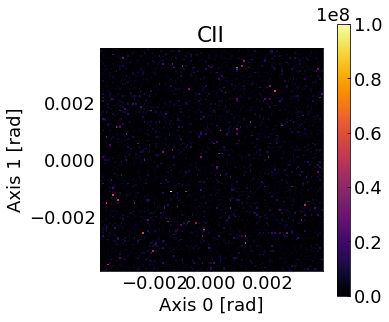

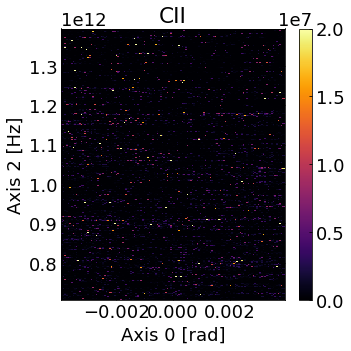

In [20]:
grid.visualize(axkws={'aspect':'equal','title':'CII'},plotkws={'cmap':'inferno','vmax':1e8})
grid.visualize(ax=(0,2),axkws={'title':'CII'},plotkws={'cmap':'inferno','vmax':2e7})

Next we can add the other three lines. We'll put each in a separate 
grid, and then sum them to get the combined signal. Note that we could
make all of these grids using a single grid object, but in order to 
conserve memory it's simpler to work with them one at a time.

In [21]:
freqs = [1461.13140620e9,2459.38010085e9,3393.00624400e9]
lines = ['LNII205','LNII122','LOIII']
paths = ['tim_grid_nii205_full_res.npz','tim_grid_nii122_full_res.npz','tim_grid_oiii_full_res.npz']

# Grid to save the combined signal
grid_sum = grid.copy()

for freq,line,path in zip(freqs,lines,paths):
    zmax = freq / fmin - 1
    zmin = freq / fmax - 1

    # Restrict galaxies to those in the relevant redshift range
    handler.set_property_range('redshift',zmin,zmax)

    # Determine locations of each galaxy
    z = handler.return_property('redshift',use_all_inds=False)
    dl = handler.cosmo.luminosity_distance(z).value
    f = freq/(1+z)

    x = handler.return_property('ra',use_all_inds=False)
    y = handler.return_property('dec',use_all_inds=False)

    positions = np.array([x,y,f]).T

    # Determine intensity of each galaxy
    luminosity = handler.return_property(line,use_all_inds=False)
    intensity = 1e26 * (luminosity*3.828e26) / (4*np.pi*(dl*3.0857e22)**2) / (df * da**2) # Intensity contribution to a cell in Jy/str

    # Grid intensities into final cube
    grid = gridder(positions,intensity,
                    center_point=[0,0,fmid],side_length=[xyrange,xyrange,fmax-fmin],pixel_size=[da,da,df],
                    axunits=['rad','rad','Hz'],gridunits='Jy/str')

    grid.save(path,overwrite=True)
    grid_sum.grid = grid_sum.grid + grid.grid
    grid_sum.n_objects = grid_sum.n_objects + grid.n_objects

grid_sum.save('tim_grid_full_res.npy',overwrite=True)

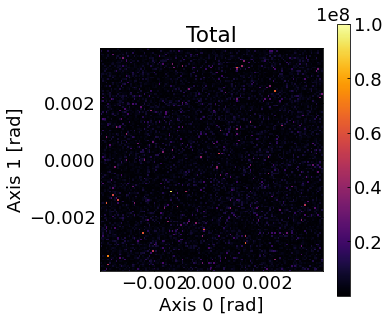

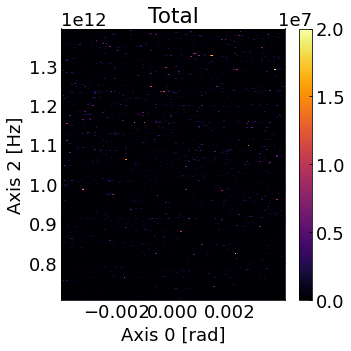

In [22]:
grid_sum.visualize(axkws={'aspect':'equal','title':'Total'},plotkws={'cmap':'inferno','vmax':1e8})
grid.visualize(ax=(0,2),axkws={'title':'Total'},plotkws={'cmap':'inferno','vmax':2e7})

## Saving and Loading Grids

Grids can be saved and reloaded as ``SimIM`` grid objects for 
further handling at a later point. The saved files are simply 
numpy zipped files containing the grid and some basic parameters
describing the axes, so if you prefer to work with the data 
without ``SimIM`` wrappers, this is also possible.

In [23]:
# Save the grid
grid_sum.save('tim_grid_full_res.npz',overwrite=True)

In [24]:
# Reload the grid - using SimIM
from simim.map import load_grid

grid_sum = load_grid('tim_grid_full_res.npz')

In [25]:
# Load the grid without SimIM
grid_npz = np.load('tim_grid_full_res.npz')
print([k for k in grid_npz.keys()])

# Create an axis describing the edges of each cell
grid_npz_axes = []
for i in range(len(grid_npz['side_length'])):
    ax = np.linspace(0,1,grid_npz['grid'].shape[i]+1) * grid_npz['side_length'][i] - grid_npz['center_point'][i]
    grid_npz_axes.append(ax)

['n_properties', 'center_point', 'side_length', 'pixel_size', 'axunits', 'gridunits', 'grid_active', 'n_objects', 'fourier_space', 'is_power_spectrum', 'grid']


``SimIM`` has some useful tools for operating on grids, so I would recommend
continuing to use the data in this format, but the best approach will depend 
on your use case. 

## Applying a Beam Response to the Map

For many purposes it will be useful to consider the beam patter of TIM
as part of our model. Here we apply a Gaussian beam with a size of 
$$\Theta=1.2\times\frac{\lambda}{D}$$ 
where $\Theta$ is the beam FWHM (in radians) $\lambda$ is the wavelength
for a given slice of our cube and $D$ is the diameter of the TIM mirror
(2 m).

We'll implement this by creating a grid containing the TIM PSF and then 
convolving it across the simulated cube.

In [38]:
from simim.map.gridder import grid_from_axes_and_function

def tim_psf(dx,dy,freq):
    """dx,dy in radians, freq in Hz"""

    x = dx.reshape(-1,1,1)
    y = dy.reshape(1,-1,1)
    fwhm = 1.2*(2.998e8/freq.reshape(1,1,-1))/2

    return np.exp(-4*np.log(2)*(x**2 + y**2)/fwhm**2)
    
ax1 = (np.arange(0,41)-20) * grid.pixel_size[0]
ax2 = (np.arange(0,41)-20) * grid.pixel_size[0]
ax3 = grid.axes[2]

tim_psf_kernel = grid_from_axes_and_function(tim_psf,ax1,ax2,ax3)

# We need to renormalize the kernel such that the total flux is preserved
tim_psf_kernel.grid = tim_psf_kernel.grid / np.sum(tim_psf_kernel.grid,axis=(0,1)).reshape(1,1,-1,1)

In [39]:
from simim.map import load_grid

grid_sum = load_grid('tim_grid_full_res.npz')
grid_sum.convolve(tim_psf_kernel,ax=[0,1],in_place=True,pad=10)
grid_sum.save('tim_grid_tim_res.npz',overwrite=True)

paths = ['tim_grid_nii205','tim_grid_nii122','tim_grid_cii','tim_grid_oiii','tim_grid_cii']
for path in paths:
    grid = load_grid(path+'_full_res.npz')
    grid.convolve(tim_psf_kernel,ax=[0,1],in_place=True,pad=10)
    grid.save(path+'_tim_res.npz',overwrite=True)

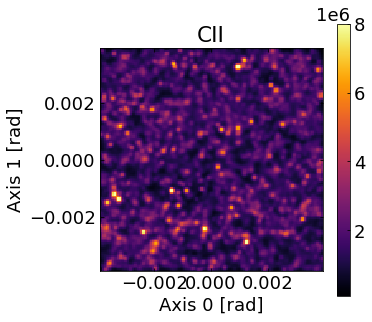

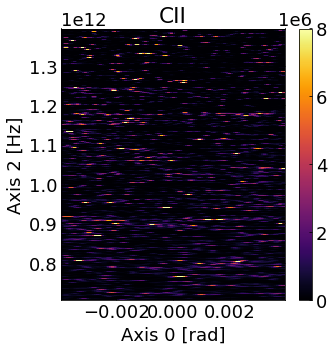

In [40]:
grid.visualize(axkws={'aspect':'equal','title':'CII'},plotkws={'cmap':'inferno','vmax':8e6})
grid.visualize(ax=(0,2),axkws={'title':'CII'},plotkws={'cmap':'inferno','vmax':8e6})

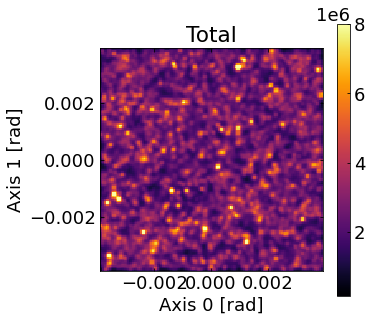

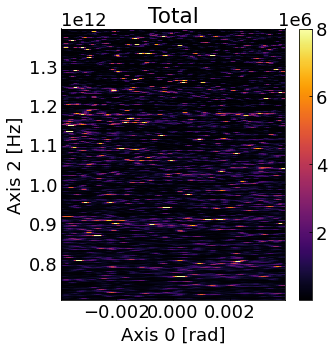

In [41]:
grid_sum.visualize(axkws={'aspect':'equal','title':'Total'},plotkws={'cmap':'inferno','vmax':8e6})
grid_sum.visualize(ax=(0,2),axkws={'title':'Total'},plotkws={'cmap':'inferno','vmax':8e6})


In [42]:
fmid/1e9

1049.9151846785228